# ⚖️ PolarQuant — Model Size Before vs After

This notebook quantizes the **K and V projection weights** of every attention layer
in **Llama 3.2 3B** using PolarQuant, saves both checkpoints to disk,
and produces a full size comparison report.

## What happens here
| Step | Description |
|------|-------------|
| 1 | Load Llama 3.2 3B in FP16 |
| 2 | Save baseline checkpoint → measure size |
| 3 | Apply PolarQuant to every `k_proj` + `v_proj` weight matrix |
| 4 | Save quantized checkpoint (indices + params) → measure size |
| 5 | Load back & verify reconstruction quality |
| 6 | Bar chart + detailed comparison table |

> **Note:** PolarQuant normally targets the *KV cache at runtime*.
> Here we apply the same polar transform to the static **weight matrices**
> of the K/V projections — giving a saveable, loadable compressed model.

**Runtime:** T4 (free Colab) · ~20 min total


## Cell 1 — Install & Imports

In [1]:
%%capture
!pip install -q transformers>=4.45.0 accelerate sentencepiece tabulate matplotlib
print('done')

In [2]:
import os, math, time, shutil, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tabulate import tabulate
from dataclasses import dataclass, field
from typing import Dict, Tuple, List

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16
SAVE_DIR = Path('/content/polarquant_checkpoints')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f'GPU : {gpu.name}  |  VRAM : {gpu.total_memory/1e9:.1f} GB')
print(f'Save dir : {SAVE_DIR}')

GPU : Tesla T4  |  VRAM : 15.6 GB
Save dir : /content/polarquant_checkpoints


## Cell 2 — HuggingFace Login

In [ ]:
from google.colab import userdata
tok = userdata.get('hf-token')

In [ ]:
from huggingface_hub import login

HF_TOKEN = tok  # ← paste token, or use Colab Secrets
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
        print('Token loaded from Colab Secrets')
    except Exception:
        HF_TOKEN = input('HuggingFace token: ').strip()

login(token=HF_TOKEN, add_to_git_credential=False)
print('Logged in ✓')

Logged in ✓


## Cell 3 — Load Llama 3.2 3B

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = 'Qwen/Qwen3-4B-Instruct-2507'
# No-token fallback:
# MODEL_ID = 'unsloth/Llama-3.2-3B-Instruct'

print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

print('Loading model (fp16)...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=DTYPE, device_map='cuda'
)
model.eval()

cfg      = model.config
n_layers = cfg.num_hidden_layers
n_heads  = cfg.num_attention_heads
n_kv     = cfg.num_key_value_heads
hid_dim  = cfg.hidden_size
head_dim = hid_dim // n_heads
kv_dim   = n_kv * head_dim        # k_proj / v_proj output dim

print(f'\nModel       : {MODEL_ID}')
print(f'Layers      : {n_layers}')
print(f'Hidden dim  : {hid_dim}')
print(f'KV heads    : {n_kv}  |  head dim : {head_dim}')
print(f'k/v proj    : ({hid_dim}, {kv_dim})  per layer')

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]


Model       : Qwen/Qwen3-4B-Instruct-2507
Layers      : 36
Hidden dim  : 2560
KV heads    : 8  |  head dim : 80
k/v proj    : (2560, 640)  per layer


## Cell 4 — Save Baseline Checkpoint
We save only the **K and V projection weights** (the part PolarQuant targets).
This keeps the comparison fair and the files manageable on Colab.

In [4]:
BASELINE_DIR = SAVE_DIR / 'baseline_kv_weights'
BASELINE_DIR.mkdir(exist_ok=True)

def collect_kv_weights(model) -> Dict[str, torch.Tensor]:
    """Extract all k_proj and v_proj weight tensors."""
    weights = {}
    for i, layer in enumerate(model.model.layers):
        attn = layer.self_attn
        weights[f'layer_{i:02d}.k_proj'] = attn.k_proj.weight.data.cpu().clone()
        weights[f'layer_{i:02d}.v_proj'] = attn.v_proj.weight.data.cpu().clone()
    return weights

print('Collecting baseline K/V weights...')
t0 = time.time()
baseline_weights = collect_kv_weights(model)

# Save as a single .pt file
baseline_path = BASELINE_DIR / 'kv_weights_fp16.pt'
torch.save(baseline_weights, baseline_path)

# Also save full model config for reference
with open(BASELINE_DIR / 'config.json', 'w') as f:
    json.dump({'model_id': MODEL_ID, 'dtype': 'float16', 'n_layers': n_layers,
               'kv_dim': kv_dim, 'hidden_dim': hid_dim}, f, indent=2)

baseline_size_mb = baseline_path.stat().st_size / 1e6
print(f'Saved → {baseline_path}')
print(f'Baseline KV weights size : {baseline_size_mb:.1f} MB')
print(f'Time : {time.time()-t0:.1f}s')

# Shape check
sample_key = 'layer_00.k_proj'
print(f'\nSample tensor {sample_key}: {baseline_weights[sample_key].shape}  dtype={baseline_weights[sample_key].dtype}')
print(f'Total tensors saved: {len(baseline_weights)}  ({n_layers} layers × 2 projections)')

Saved → /content/polarquant_checkpoints/baseline_kv_weights/kv_weights_fp16.pt
Baseline KV weights size : 377.5 MB
Time : 1.1s

Sample tensor layer_00.k_proj: torch.Size([1024, 2560])  dtype=torch.float16
Total tensors saved: 72  (36 layers × 2 projections)


## Cell 5 — PolarQuant Weight Quantizer

We quantize each weight matrix **row-wise**:
- Each row (= one output neuron) is treated as a vector
- Precondition with a random rotation, then apply pair-wise polar transform
- Store 4-bit angles + 2-bit radii + per-row scale/offset

This compresses `float16` (16 bits) down to **~3 bits per element**.

In [5]:
class PolarQuantWeight:
    """
    PolarQuant applied to a 2-D weight matrix W of shape (out_dim, in_dim).
    Quantizes row-by-row.

    Compressed format:
      - angle_idx   : uint8  (out, in//2)   — 4 bits packed
      - radius_idx  : uint8  (out, in//2)   — 2 bits packed
      - angle_min   : fp16   (out, 1)
      - angle_scale : fp16   (out, 1)
      - radius_min  : fp16   (out, 1)
      - radius_scale: fp16   (out, 1)
      - rotation S  : fp16   (in, in)
    """

    def __init__(self, in_dim: int, n_bits_angle: int = 4, n_bits_radius: int = 2):
        assert in_dim % 2 == 0
        self.in_dim          = in_dim
        self.n_bits_angle    = n_bits_angle
        self.n_bits_radius   = n_bits_radius
        self.n_lvl_a         = 2 ** n_bits_angle   # 16
        self.n_lvl_r         = 2 ** n_bits_radius  # 4

        # Random orthogonal rotation (float32 for stability, then cast)
        G = torch.randn(in_dim, in_dim)
        Q, _ = torch.linalg.qr(G.float())
        self.S = Q.half()  # (in_dim, in_dim)

    # ── core math ─────────────────────────────────────────────────

    def _rotate(self, W: torch.Tensor) -> torch.Tensor:
        """W: (out, in) → (out, in), rows rotated"""
        return (W.float() @ self.S.T.float()).half()

    def _unrotate(self, W: torch.Tensor) -> torch.Tensor:
        return (W.float() @ self.S.float()).half()

    @staticmethod
    def _to_polar(W: torch.Tensor):
        """(out, in) → radii (out, in//2),  angles (out, in//2) in [0,2π)"""
        xe     = W[:, 0::2]
        xo     = W[:, 1::2]
        radii  = torch.sqrt(xe**2 + xo**2)
        angles = (torch.atan2(xo, xe) + 2*math.pi) % (2*math.pi)
        return radii, angles

    @staticmethod
    def _from_polar(radii, angles):
        """→ (out, in)"""
        xe = radii * torch.cos(angles)
        xo = radii * torch.sin(angles)
        return torch.stack([xe, xo], dim=-1).flatten(-2)

    def _quant(self, X: torch.Tensor, n_lvl: int):
        """Per-row min-max quantization. Returns (idx uint8, min fp16, scale fp16)."""
        mn  = X.min(dim=1, keepdim=True).values
        mx  = X.max(dim=1, keepdim=True).values
        sc  = (mx - mn) / (n_lvl - 1 + 1e-8)
        idx = ((X - mn) / (sc + 1e-8)).round().clamp(0, n_lvl-1).to(torch.uint8)
        return idx, mn.half(), sc.half()

    def _dequant(self, idx, mn, sc):
        return idx.half() * sc + mn

    # ── public ────────────────────────────────────────────────────

    def compress(self, W: torch.Tensor) -> dict:
        """W: (out, in) fp16 → compressed dict"""
        W = W.cpu()
        Wr = self._rotate(W)                              # precondition
        radii, angles = self._to_polar(Wr)                # polar
        a_idx, a_mn, a_sc = self._quant(angles.float(), self.n_lvl_a)
        r_idx, r_mn, r_sc = self._quant(radii.float(),  self.n_lvl_r)
        return dict(
            a_idx=a_idx, a_mn=a_mn, a_sc=a_sc,
            r_idx=r_idx, r_mn=r_mn, r_sc=r_sc,
            shape=W.shape
        )

    def decompress(self, c: dict) -> torch.Tensor:
        """→ (out, in) fp16 approximate reconstruction"""
        angles = self._dequant(c['a_idx'], c['a_mn'], c['a_sc'])
        radii  = self._dequant(c['r_idx'], c['r_mn'], c['r_sc'])
        Wr     = self._from_polar(radii, angles)
        return self._unrotate(Wr)

    def bits_per_element(self) -> float:
        # n_bits_angle for angles + n_bits_radius for radii per pair → /2 per element
        # Plus 4 fp16 scale/offset per row: 4*2 bytes / in_dim elements per row
        data_bits = (self.n_bits_angle + self.n_bits_radius) / 2
        overhead  = (4 * 16) / self.in_dim  # 4 fp16 values spread over in_dim cols
        return data_bits + overhead


# Quick unit test
pqw = PolarQuantWeight(in_dim=hid_dim, n_bits_angle=4, n_bits_radius=2)
W_test = torch.randn(kv_dim, hid_dim, dtype=torch.float16)
W_rec  = pqw.decompress(pqw.compress(W_test))
cos    = F.cosine_similarity(W_test, W_rec).mean().item()
print(f'PolarQuantWeight sanity check')
print(f'  Weight shape   : {W_test.shape}')
print(f'  Cosine sim     : {cos:.4f}')
print(f'  Bits/element   : {pqw.bits_per_element():.2f}  (vs 16 for fp16 → {16/pqw.bits_per_element():.1f}×)')

PolarQuantWeight sanity check
  Weight shape   : torch.Size([640, 2560])
  Cosine sim     : 0.9585
  Bits/element   : 3.02  (vs 16 for fp16 → 5.3×)


## Cell 6 — Quantize All K/V Weights & Save

Loops over all `n_layers` layers, compresses each `k_proj` and `v_proj`,
and saves the full quantized state to disk.

In [6]:
PQ_DIR = SAVE_DIR / 'polarquant_kv_weights'
PQ_DIR.mkdir(exist_ok=True)

N_BITS_ANGLE  = 4
N_BITS_RADIUS = 2

pqw = PolarQuantWeight(
    in_dim=hid_dim,
    n_bits_angle=N_BITS_ANGLE,
    n_bits_radius=N_BITS_RADIUS
)

quantized_state = {}   # layer_name → compressed dict
per_layer_stats = []   # for plotting

print(f'Quantizing {n_layers} layers × 2 projections ({N_BITS_ANGLE}-bit θ, {N_BITS_RADIUS}-bit r)...')
t0 = time.time()

for i, layer in enumerate(model.model.layers):
    for proj_name in ('k_proj', 'v_proj'):
        W      = getattr(layer.self_attn, proj_name).weight.data  # (kv_dim, hid_dim)
        c      = pqw.compress(W)
        key    = f'layer_{i:02d}.{proj_name}'
        quantized_state[key] = c

        # Per-layer cosine sim for diagnostics
        W_rec  = pqw.decompress(c)
        cos    = F.cosine_similarity(W.cpu(), W_rec).mean().item()
        per_layer_stats.append({'layer': i, 'proj': proj_name, 'cos_sim': cos})

    if (i+1) % 5 == 0 or i == n_layers - 1:
        print(f'  [{i+1:02d}/{n_layers}] layer {i:02d} — k cos:{per_layer_stats[-2]["cos_sim"]:.4f}  v cos:{per_layer_stats[-1]["cos_sim"]:.4f}')

# Save quantized state + rotation matrix + config
pq_path = PQ_DIR / f'kv_polarquant_{N_BITS_ANGLE}bit_angle_{N_BITS_RADIUS}bit_radius.pt'
torch.save({
    'state':          quantized_state,
    'rotation_S':     pqw.S,           # shared rotation matrix
    'n_bits_angle':   N_BITS_ANGLE,
    'n_bits_radius':  N_BITS_RADIUS,
    'in_dim':         hid_dim,
    'kv_dim':         kv_dim,
    'n_layers':       n_layers,
    'model_id':       MODEL_ID,
}, pq_path)

pq_size_mb = pq_path.stat().st_size / 1e6
print(f'\nSaved → {pq_path}')
print(f'Time : {time.time()-t0:.1f}s')

Quantizing 36 layers × 2 projections (4-bit θ, 2-bit r)...
  [05/36] layer 04 — k cos:0.9580  v cos:0.9585
  [10/36] layer 09 — k cos:0.9580  v cos:0.9580
  [15/36] layer 14 — k cos:0.9580  v cos:0.9580
  [20/36] layer 19 — k cos:0.9585  v cos:0.9585
  [25/36] layer 24 — k cos:0.9585  v cos:0.9580
  [30/36] layer 29 — k cos:0.9585  v cos:0.9585
  [35/36] layer 34 — k cos:0.9585  v cos:0.9580
  [36/36] layer 35 — k cos:0.9580  v cos:0.9585

Saved → /content/polarquant_checkpoints/polarquant_kv_weights/kv_polarquant_4bit_angle_2bit_radius.pt
Time : 49.4s


## Cell 7 — Size Comparison & Metrics

In [13]:
# ── Compute sizes ────────────────────────────────────────────────
baseline_size_mb = baseline_path.stat().st_size / 1e6
pq_size_mb       = pq_path.stat().st_size / 1e6
compression      = baseline_size_mb / pq_size_mb
savings_mb       = baseline_size_mb - pq_size_mb

# ── Theoretical from bit analysis ───────────────────────────────
total_kv_elements = n_layers * 2 * kv_dim * hid_dim   # k+v, all layers
fp16_bytes        = total_kv_elements * 2
bpe               = pqw.bits_per_element()
theory_bytes      = total_kv_elements * bpe / 8
theory_ratio      = fp16_bytes / theory_bytes

# ── Cosine sim stats ─────────────────────────────────────────────
all_cos   = [s['cos_sim'] for s in per_layer_stats]
k_cos     = [s['cos_sim'] for s in per_layer_stats if s['proj']=='k_proj']
v_cos     = [s['cos_sim'] for s in per_layer_stats if s['proj']=='v_proj']

# ── Print table ──────────────────────────────────────────────────
table = [
    ['Metric',                          'Baseline (FP16)',            f'PolarQuant ({N_BITS_ANGLE}-bit θ / {N_BITS_RADIUS}-bit r)'],
    ['KV weight file size',             f'{baseline_size_mb:.1f} MB', f'{pq_size_mb:.1f} MB'],
    ['Bits per element',                '16',                         f'{bpe:.2f}'],
    ['Compression ratio (actual)',      '1.00×',                      f'{compression:.2f}×'],
    ['Compression ratio (theoretical)', '1.00×',                      f'{theory_ratio:.2f}×'],
    ['Disk savings',                    '—',                          f'{savings_mb:.1f} MB ({(1-1/compression)*100:.1f}%)'],
    ['Mean cosine sim (k_proj)',         '1.0000',                     f'{np.mean(k_cos):.4f}'],
    ['Mean cosine sim (v_proj)',         '1.0000',                     f'{np.mean(v_cos):.4f}'],
    ['Min  cosine sim (all)',            '1.0000',                     f'{min(all_cos):.4f}'],
]

print('\n' + '═'*72)
print('  POLARQUANT MODEL SIZE COMPARISON — Qwen/Qwen3-4B-Instruct-2507 (KV Projections)')
print('═'*72)
print(tabulate(table[1:], headers=table[0], tablefmt='rounded_outline'))
print()
print(f'  Saved files:')
print(f'    Baseline  → {baseline_path}')
print(f'    PolarQuant→ {pq_path}')


════════════════════════════════════════════════════════════════════════
  POLARQUANT MODEL SIZE COMPARISON — Qwen/Qwen3-4B-Instruct-2507 (KV Projections)
════════════════════════════════════════════════════════════════════════
╭─────────────────────────────────┬───────────────────┬──────────────────────────────────╮
│ Metric                          │ Baseline (FP16)   │ PolarQuant (4-bit θ / 2-bit r)   │
├─────────────────────────────────┼───────────────────┼──────────────────────────────────┤
│ KV weight file size             │ 377.5 MB          │ 202.6 MB                         │
│ Bits per element                │ 16                │ 3.02                             │
│ Compression ratio (actual)      │ 1.00×             │ 1.86×                            │
│ Compression ratio (theoretical) │ 1.00×             │ 5.29×                            │
│ Disk savings                    │ —                 │ 174.9 MB (46.3%)                 │
│ Mean cosine sim (k_proj)        │ 1.0000 

## Cell 8 — Visualizations

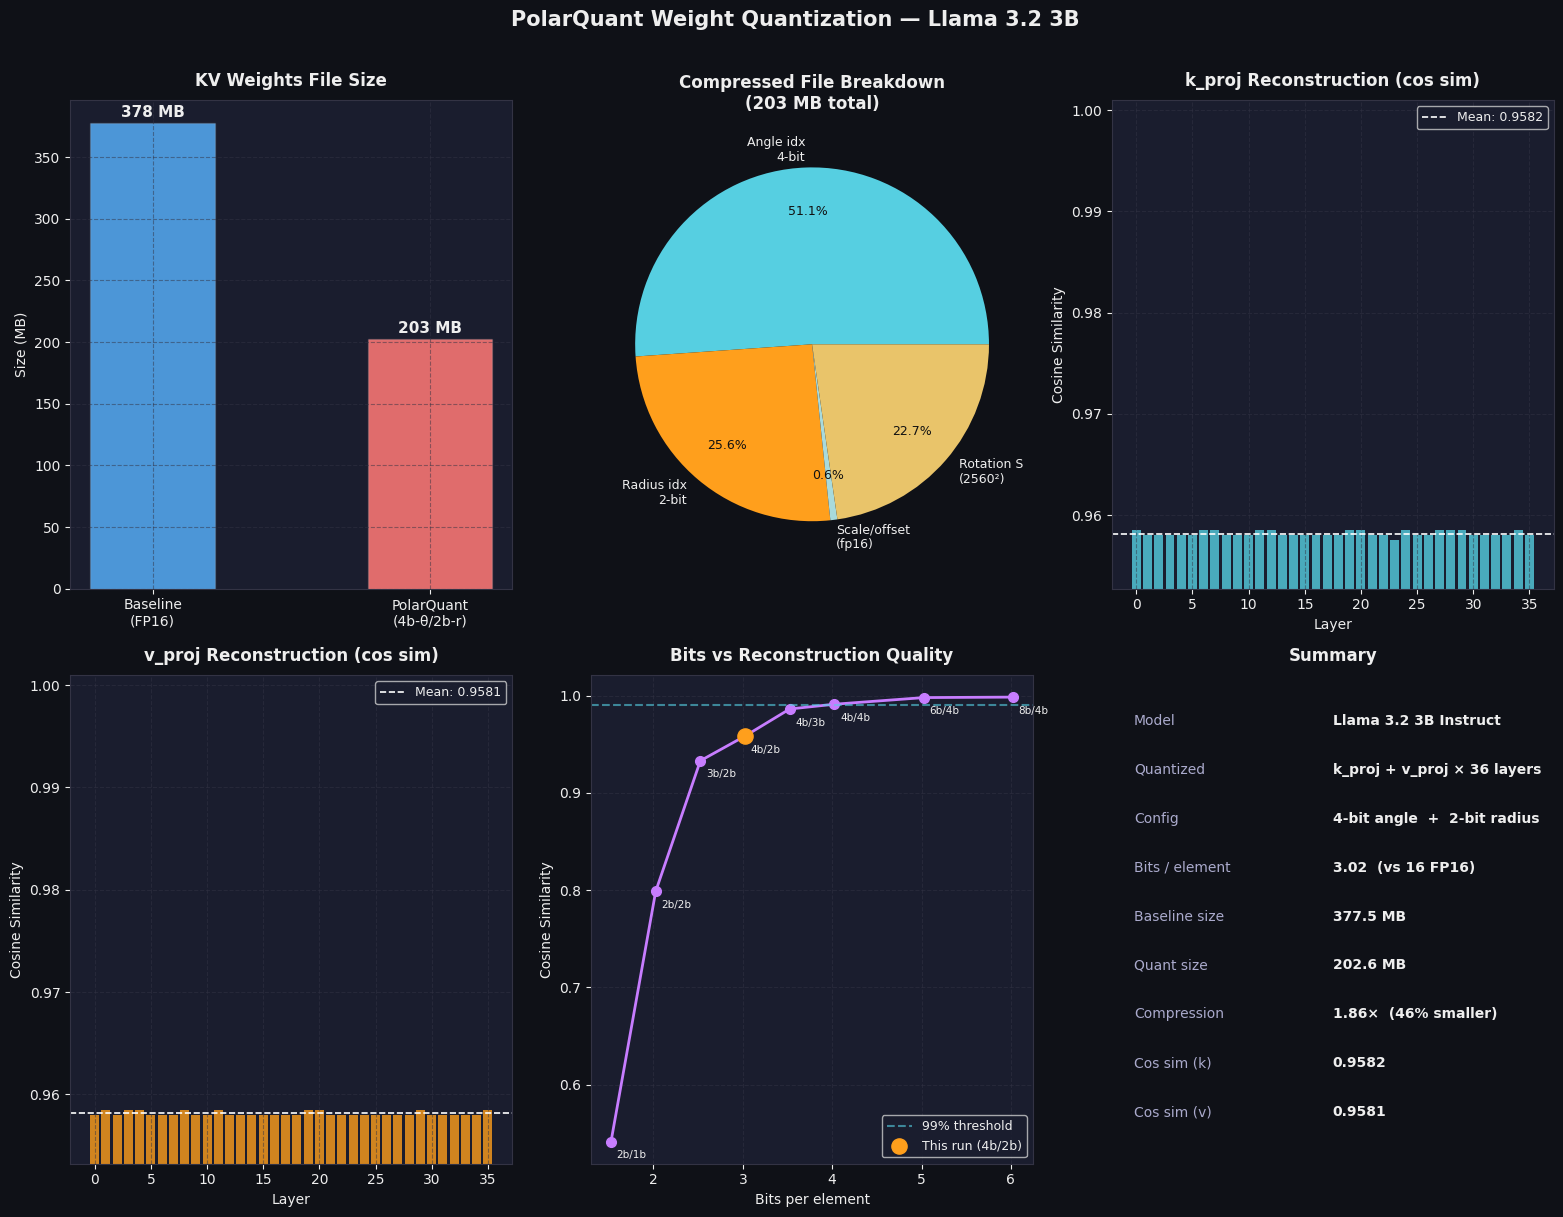

Chart saved → /content/polarquant_checkpoints/polarquant_size_comparison.png


In [8]:
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0f1117')

COLORS = {'base': '#4C96D7', 'pq': '#E06C6C', 'k': '#56CFE1', 'v': '#FF9F1C',
          'text': '#EEEEEE', 'grid': '#333344'}

def style_ax(ax, title):
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors=COLORS['text'])
    ax.xaxis.label.set_color(COLORS['text'])
    ax.yaxis.label.set_color(COLORS['text'])
    ax.title.set_color(COLORS['text'])
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333344')
    ax.grid(color=COLORS['grid'], linestyle='--', alpha=0.5)


# ── 1. Bar: File sizes ────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
bars = ax1.bar(['Baseline\n(FP16)', f'PolarQuant\n({N_BITS_ANGLE}b-θ/{N_BITS_RADIUS}b-r)'],
               [baseline_size_mb, pq_size_mb],
               color=[COLORS['base'], COLORS['pq']], width=0.45, edgecolor='#ffffff22')
for b, v in zip(bars, [baseline_size_mb, pq_size_mb]):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+5,
             f'{v:.0f} MB', ha='center', color=COLORS['text'], fontsize=11, fontweight='bold')
ax1.set_ylabel('Size (MB)', color=COLORS['text'])
style_ax(ax1, 'KV Weights File Size')


# ── 2. Pie: Compression breakdown ────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
# What makes up the compressed file?
n_pairs   = n_layers * 2 * kv_dim * (hid_dim // 2)
a_bytes   = n_pairs * N_BITS_ANGLE  // 8
r_bytes   = n_pairs * N_BITS_RADIUS // 8
# scale/offset: per row, 4 values fp16 (a_mn, a_sc, r_mn, r_sc)
so_bytes  = n_layers * 2 * kv_dim * 4 * 2
rot_bytes = hid_dim * hid_dim * 2
slices    = [a_bytes/1e6, r_bytes/1e6, so_bytes/1e6, rot_bytes/1e6]
labels    = [f'Angle idx\n{N_BITS_ANGLE}-bit', f'Radius idx\n{N_BITS_RADIUS}-bit',
             'Scale/offset\n(fp16)', f'Rotation S\n({hid_dim}²)']
clrs      = ['#56CFE1','#FF9F1C','#A8DADC','#E9C46A']
wedges, texts, autotexts = ax2.pie(
    slices, labels=labels, colors=clrs, autopct='%1.1f%%',
    textprops={'color': COLORS['text'], 'fontsize': 9},
    pctdistance=0.75
)
for at in autotexts: at.set_color('#111')
style_ax(ax2, f'Compressed File Breakdown\n({pq_size_mb:.0f} MB total)')
ax2.grid(False)


# ── 3. Per-layer cosine sim: k_proj ──────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
layers_idx = list(range(n_layers))
ax3.bar(layers_idx, k_cos, color=COLORS['k'], alpha=0.8)
ax3.axhline(np.mean(k_cos), color='white', linestyle='--', linewidth=1.2,
            label=f'Mean: {np.mean(k_cos):.4f}')
ax3.set_ylim(min(k_cos)*0.995, 1.001)
ax3.set_xlabel('Layer', color=COLORS['text'])
ax3.set_ylabel('Cosine Similarity', color=COLORS['text'])
ax3.legend(facecolor='#1a1d2e', labelcolor=COLORS['text'], fontsize=9)
style_ax(ax3, 'k_proj Reconstruction (cos sim)')


# ── 4. Per-layer cosine sim: v_proj ──────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
ax4.bar(layers_idx, v_cos, color=COLORS['v'], alpha=0.8)
ax4.axhline(np.mean(v_cos), color='white', linestyle='--', linewidth=1.2,
            label=f'Mean: {np.mean(v_cos):.4f}')
ax4.set_ylim(min(v_cos)*0.995, 1.001)
ax4.set_xlabel('Layer', color=COLORS['text'])
ax4.set_ylabel('Cosine Similarity', color=COLORS['text'])
ax4.legend(facecolor='#1a1d2e', labelcolor=COLORS['text'], fontsize=9)
style_ax(ax4, 'v_proj Reconstruction (cos sim)')


# ── 5. Bits ablation curve ───────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
configs_ab = [(8,4),(6,4),(4,4),(4,3),(4,2),(3,2),(2,2),(2,1)]
ab_bpe, ab_cos = [], []
W_ab = torch.randn(kv_dim, hid_dim, dtype=torch.float16)
for na, nr in configs_ab:
    pq_ab = PolarQuantWeight(hid_dim, na, nr)
    Wr = pq_ab.decompress(pq_ab.compress(W_ab))
    cos_ab = F.cosine_similarity(W_ab, Wr).mean().item()
    ab_bpe.append(pq_ab.bits_per_element())
    ab_cos.append(cos_ab)

ax5.plot(ab_bpe, ab_cos, 'o-', color='#C77DFF', markersize=7, linewidth=2)
for bpe_pt, cos_pt, (na,nr) in zip(ab_bpe, ab_cos, configs_ab):
    ax5.annotate(f'{na}b/{nr}b', (bpe_pt, cos_pt),
                 textcoords='offset points', xytext=(4,-12),
                 fontsize=7.5, color=COLORS['text'])
ax5.axhline(0.99, color='#56CFE1', linestyle='--', alpha=0.6, label='99% threshold')
ax5.scatter([bpe], [np.mean(all_cos)], s=120, color='#FF9F1C', zorder=5,
            label=f'This run ({N_BITS_ANGLE}b/{N_BITS_RADIUS}b)')
ax5.set_xlabel('Bits per element', color=COLORS['text'])
ax5.set_ylabel('Cosine Similarity', color=COLORS['text'])
ax5.legend(facecolor='#1a1d2e', labelcolor=COLORS['text'], fontsize=9)
style_ax(ax5, 'Bits vs Reconstruction Quality')


# ── 6. Summary stats ─────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
style_ax(ax6, 'Summary')

lines = [
    ('Model',           'Llama 3.2 3B Instruct'),
    ('Quantized',       f'k_proj + v_proj × {n_layers} layers'),
    ('Config',          f'{N_BITS_ANGLE}-bit angle  +  {N_BITS_RADIUS}-bit radius'),
    ('Bits / element',  f'{bpe:.2f}  (vs 16 FP16)'),
    ('Baseline size',   f'{baseline_size_mb:.1f} MB'),
    ('Quant size',      f'{pq_size_mb:.1f} MB'),
    ('Compression',     f'{compression:.2f}×  ({(1-1/compression)*100:.0f}% smaller)'),
    ('Cos sim (k)',     f'{np.mean(k_cos):.4f}'),
    ('Cos sim (v)',     f'{np.mean(v_cos):.4f}'),
]
y = 0.92
for label, val in lines:
    ax6.text(0.05, y, label, fontsize=10, color='#AAAACC',
             transform=ax6.transAxes, va='top')
    ax6.text(0.50, y, val,   fontsize=10, color=COLORS['text'],
             transform=ax6.transAxes, va='top', fontweight='bold')
    y -= 0.10


plt.suptitle('PolarQuant Weight Quantization — Llama 3.2 3B',
             color=COLORS['text'], fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = SAVE_DIR / 'polarquant_size_comparison.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Chart saved → {fig_path}')

## Cell 9 — Load Back & Verify

Reload the quantized checkpoint from disk and verify the weights reconstruct correctly.

In [9]:
print('Loading quantized checkpoint back from disk...')
t0 = time.time()
ckpt = torch.load(pq_path, map_location='cpu', weights_only=False)
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'Keys in checkpoint: {list(ckpt.keys())}')

# Reconstruct a PolarQuantWeight with the saved rotation matrix
pqw_reloaded = PolarQuantWeight(
    in_dim       = ckpt['in_dim'],
    n_bits_angle = ckpt['n_bits_angle'],
    n_bits_radius= ckpt['n_bits_radius'],
)
pqw_reloaded.S = ckpt['rotation_S']  # restore the exact rotation used at compression time

# Spot-check 5 random layers
print('\nSpot-checking reconstructed weights vs originals:')
rows = []
import random
random.seed(42)
spot_layers = random.sample(range(n_layers), min(5, n_layers))

for i in spot_layers:
    for proj in ('k_proj', 'v_proj'):
        key    = f'layer_{i:02d}.{proj}'
        c      = ckpt['state'][key]
        W_rec  = pqw_reloaded.decompress(c)
        W_orig = getattr(model.model.layers[i].self_attn, proj).weight.data.cpu()
        cos    = F.cosine_similarity(W_orig, W_rec).mean().item()
        l2_rel = ((W_orig - W_rec).norm() / W_orig.norm()).item()
        rows.append([key, f'{cos:.5f}', f'{l2_rel:.5f}'])

print(tabulate(rows, headers=['Weight', 'Cosine Sim', 'Rel L2 Error'], tablefmt='rounded_outline'))
print('\n✅ Checkpoint verified — weights reconstruct correctly after save/load')

Loading quantized checkpoint back from disk...
Loaded in 0.1s
Keys in checkpoint: ['state', 'rotation_S', 'n_bits_angle', 'n_bits_radius', 'in_dim', 'kv_dim', 'n_layers', 'model_id']

Spot-checking reconstructed weights vs originals:
╭─────────────────┬──────────────┬────────────────╮
│ Weight          │   Cosine Sim │   Rel L2 Error │
├─────────────────┼──────────────┼────────────────┤
│ layer_07.k_proj │      0.9585  │        0.2981  │
│ layer_07.v_proj │      0.95801 │        0.2981  │
│ layer_01.k_proj │      0.95801 │        0.29956 │
│ layer_01.v_proj │      0.9585  │        0.29712 │
│ layer_17.k_proj │      0.95801 │        0.29858 │
│ layer_17.v_proj │      0.95801 │        0.29858 │
│ layer_15.k_proj │      0.95801 │        0.29907 │
│ layer_15.v_proj │      0.95801 │        0.29907 │
│ layer_14.k_proj │      0.95801 │        0.29883 │
│ layer_14.v_proj │      0.95801 │        0.29858 │
╰─────────────────┴──────────────┴────────────────╯

✅ Checkpoint verified — weights recon

## Cell 10 — Inject Quantized Weights & Generate

Replace the model's `k_proj` and `v_proj` weights with their PolarQuant reconstructions
and run a generation to confirm the model still works end-to-end.

In [10]:
print('Injecting quantized weights into model...')
with torch.no_grad():
    for i, layer in enumerate(model.model.layers):
        for proj in ('k_proj', 'v_proj'):
            key   = f'layer_{i:02d}.{proj}'
            W_rec = pqw_reloaded.decompress(ckpt['state'][key]).to(DEVICE).to(DTYPE)
            getattr(layer.self_attn, proj).weight.data.copy_(W_rec)

print('✅ Weights injected')

# Generate
PROMPT = 'Describe the key difference between RNNs and Transformers in two sentences.'
messages = [{'role': 'user', 'content': PROMPT}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(text, return_tensors='pt').to(DEVICE)

with torch.inference_mode():
    out = model.generate(
        **inputs, max_new_tokens=120, temperature=0.7,
        do_sample=True, pad_token_id=tokenizer.eos_token_id
    )

generated = out[0][inputs['input_ids'].shape[1]:]
result    = tokenizer.decode(generated, skip_special_tokens=True)

print('\nPrompt  :', PROMPT)
print('Response:', result)

Injecting quantized weights into model...
✅ Weights injected

Prompt  : Describe the key difference between RNNs and Transformers in two sentences.
Response: Recurrent Neural Networks (RNNs) process sequences step-by-step, maintaining a hidden state that captures dependencies across time, but struggle with long-range dependencies due to vanishing gradients. Transformers, in contrast, rely entirely on self-attention mechanisms to model relationships between all elements in a sequence simultaneously, enabling efficient handling of long-range dependencies and parallel processing.


## Cell 11 — Directory Listing & Final Summary

In [11]:
print('\n📁 Files saved to', SAVE_DIR)
print()
for f in sorted(SAVE_DIR.rglob('*')):
    size = f.stat().st_size / 1e6 if f.is_file() else 0
    indent = '  ' * (len(f.parts) - len(SAVE_DIR.parts) - 1)
    if f.is_dir():
        print(f'{indent}📂 {f.name}/')
    else:
        print(f'{indent}📄 {f.name}  ({size:.1f} MB)')

print('\n' + '═'*60)
print('  ✅ COMPLETE')
print(f'  Baseline KV weights  : {baseline_size_mb:.1f} MB')
print(f'  PolarQuant KV weights: {pq_size_mb:.1f} MB')
print(f'  Compression ratio    : {compression:.2f}×')
print(f'  Disk saved           : {savings_mb:.1f} MB ({(1-1/compression)*100:.0f}% reduction)')
print(f'  Mean cosine sim      : {np.mean(all_cos):.4f}')
print('═'*60)


📁 Files saved to /content/polarquant_checkpoints

📂 baseline_kv_weights/
  📄 config.json  (0.0 MB)
  📄 kv_weights_fp16.pt  (377.5 MB)
📂 polarquant_kv_weights/
  📄 kv_polarquant_4bit_angle_2bit_radius.pt  (202.6 MB)
📄 polarquant_size_comparison.png  (0.3 MB)

════════════════════════════════════════════════════════════
  ✅ COMPLETE
  Baseline KV weights  : 377.5 MB
  PolarQuant KV weights: 202.6 MB
  Compression ratio    : 1.86×
  Disk saved           : 174.9 MB (46% reduction)
  Mean cosine sim      : 0.9581
════════════════════════════════════════════════════════════
